# **Marketing Bancario**

# **Abstracto**

En el contexto de la creciente competitividad del sector financiero, las entidades bancarias enfrentan el desafío de optimizar sus campañas de marketing directo con el fin de maximizar la captación de clientes y, al mismo tiempo, reducir costos operativos. Este trabajo se dirige a una audiencia compuesta por analistas de datos, científicos de datos y responsables de áreas comerciales, interesados en la aplicación de técnicas de Data Science para la toma de decisiones estratégicas basadas en datos.

#**Contexto Comercial**

El presente análisis se apoya en el Bank Marketing Dataset del repositorio UCI, el cual contiene información sociodemográfica, financiera y de interacción comercial de clientes contactados durante campañas de marketing para la suscripción de depósitos a plazo fijo. Desde una perspectiva comercial, el problema central consiste en identificar qué características de los clientes y qué variables asociadas a la interacción influyen en la probabilidad de suscripción del producto financiero. Desde el punto de vista analítico, el dataset plantea un problema de clasificación binaria, donde el objetivo es predecir si un cliente aceptará o no la oferta del producto.



# **Hipotesis**

La hipótesis principal de este estudio sostiene que existen patrones significativos en las variables demográficas, económicas y de comportamiento de contacto que permiten diferenciar a los clientes con mayor propensión a suscribirse a un depósito a plazo. En particular, se plantea que factores como la edad, el balance promedio, el historial de campañas previas y el tipo de contacto influyen de manera relevante en el resultado de la campaña. Asimismo, se evalúa la hipótesis secundaria de que una correcta selección de clientes puede mejorar la eficiencia de las campañas, reduciendo el número de contactos innecesarios.

# **Objetivo**




El objetivo de este trabajo es explorar, analizar y modelar los datos disponibles con el fin de extraer conocimiento accionable que permita comprender el comportamiento de los clientes y apoyar la toma de decisiones comerciales. A través del análisis exploratorio de datos y la aplicación de técnicas de Machine Learning, se busca construir un marco analítico que sirva como base para el diseño de campañas de marketing más efectivas y orientadas a datos.

# Lectura de Datos

Librerias necesarias para el analisis de datos

In [ ]:
#importamos librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

Importación y lectura del dataset

In [ ]:
#importamos y leemos el csv de carpeta de drive
url = '/content/drive/MyDrive/CODERHOUSE/Data Science I/Entrega I/bank.csv'
df = pd.read_csv(url, delimiter=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


# **Tabla de Variables**
---

| **Nombre de Variable** | **Rol**    | **Tipo de Dato**     | **Descripción**                                                             |
| ---------------------- | ---------- | -------------------- | --------------------------------------------------------------------------- |
| `age`                  | Feature    | Entero (numérico)    | Edad del cliente                                                            |
| `job`                  | Feature    | Categórica           | Tipo de trabajo (`admin.`, `blue-collar`, `entrepreneur`, etc.)             |
| `marital`              | Feature    | Categórica           | Estado civil (`married`, `divorced`, `single`)                              |
| `education`            | Feature    | Categórica           | Nivel educativo (`secondary`, `primary`, `tertiary`, `unknown`)             |
| `default`              | Feature    | Binaria / Categórica | ¿Tiene crédito en default? (`yes`, `no`)                                    |
| `balance`              | Feature    | Entero (numérico)    | Balance promedio anual en euros                                             |
| `housing`              | Feature    | Binaria              | ¿Tiene préstamo hipotecario? (`yes`, `no`)                                  |
| `loan`                 | Feature    | Binaria              | ¿Tiene préstamo personal? (`yes`, `no`)                                     |
| `contact`              | Feature    | Categórica           | Tipo de contacto (`cellular`, `telephone`)                                  |
| `day_of_week`          | Feature    | Categórica           | Día de la semana del último contacto (`mon`, `tue`, ..., `fri`)             |
| `month`                | Feature    | Categórica           | Mes del último contacto (`jan` … `dec`)                                     |
| `duration`             | Feature    | Entero (numérico)    | Duración de la última llamada (segundos)                                    |
| `campaign`             | Feature    | Entero (numérico)    | Número de contactos realizados en esta campaña                              |
| `pdays`                | Feature    | Entero (numérico)    | Días desde el último contacto previo (-1 o `999` significa no contactado)   |
| `previous`             | Feature    | Entero (numérico)    | Número de contactos realizados antes de esta campaña                        |
| `poutcome`             | Feature    | Categórica           | Resultado de la campaña anterior (`unknown`, `other`, `failure`, `success`) |
| `y`                    | **Target** | Binaria              | ¿Cliente suscribió depósito a plazo? (`yes`, `no`)                          |


Tamaño del dataset

In [ ]:
#dimension del dataset
df.shape

(4521, 17)

Descripción de Variables

In [ ]:
#columnas de Dataset
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
#informacion del dataset, valores nulos y tipo de datos para las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
#descripcion del dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4521.0,41.170095,10.576211,19.0,33.0,39.0,49.0,87.0
balance,4521.0,1422.657819,3009.638142,-3313.0,69.0,444.0,1480.0,71188.0
day,4521.0,15.915284,8.247667,1.0,9.0,16.0,21.0,31.0
duration,4521.0,263.961292,259.856633,4.0,104.0,185.0,329.0,3025.0
campaign,4521.0,2.793630,3.109807,1.0,1.0,2.0,3.0,50.0
pdays,4521.0,39.766645,100.121124,-1.0,-1.0,-1.0,-1.0,871.0
previous,4521.0,0.542579,1.693562,0.0,0.0,0.0,0.0,25.0


In [ ]:
df.describe(include = ['object']).T

,count,unique,top,freq
job,4521,12,management,969
marital,4521,3,married,2797
education,4521,4,secondary,2306
default,4521,2,no,4445
housing,4521,2,yes,2559
loan,4521,2,no,3830
contact,4521,3,cellular,2896
month,4521,12,may,1398
poutcome,4521,4,unknown,3705
y,4521,2,no,4000


In [ ]:
df.select_dtypes(include='object').apply(pd.unique)


,0
job,"[unemployed, services, management, blue-collar..."
marital,"[married, single, divorced]"
education,"[primary, secondary, tertiary, unknown]"
default,"[no, yes]"
housing,"[no, yes]"
loan,"[no, yes]"
contact,"[cellular, unknown, telephone]"
month,"[oct, may, apr, jun, feb, aug, jan, jul, nov, ..."
poutcome,"[unknown, failure, other, success]"
y,"[no, yes]"


# Data Wrangling: Limpieza y Transformación de Datos

Valores nulos

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Valores Duplicados

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4516,False
4517,False
4518,False
4519,False


Missing Values

In [ ]:
missing_values = df.isna().sum()

missing_values[missing_values > 0]

,0


Valores Unknown:

Algunas variables categóricas contienen el valor "unknown", que representa información faltante o no registrada.

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(col, (df[col] == "unknown").sum())

job 38
marital 0
education 187
default 0
housing 0
loan 0
contact 1324
month 0
poutcome 3705
y 0


Pdays:

La variable pdays indica la cantidad de días transcurridos desde el último contacto con el cliente en una campaña anterior. Un valor de -1 indica que el cliente no fue contactado previamente, por lo que no representa un valor válido sino una codificación especial.

In [ ]:
(df["pdays"] == -1).sum()

np.int64(3705)

# EDA : Analisis Exploratorio de datos

Conteo total de la variable 'Y'

<Axes: xlabel='y', ylabel='count'>

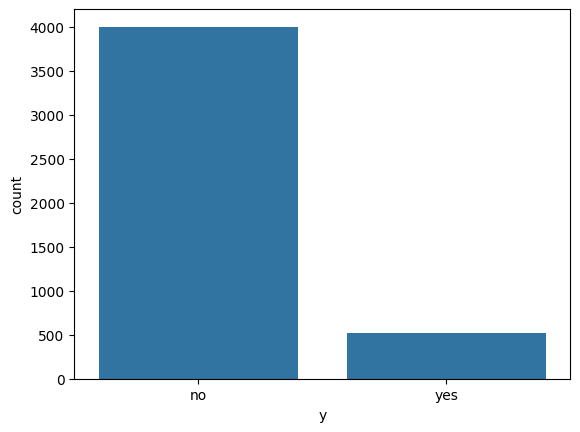

In [ ]:
sns.countplot(data=df,x='y')

Se observa que el dataset presenta un desbalance entre las clases, con una mayor proporción de clientes que no aceptan la campaña (no). Este tipo de desbalance puede afectar el desempeño de los modelos de clasificación.

Cantidad de clientes contactados segun la edad

<Axes: xlabel='age', ylabel='Count'>

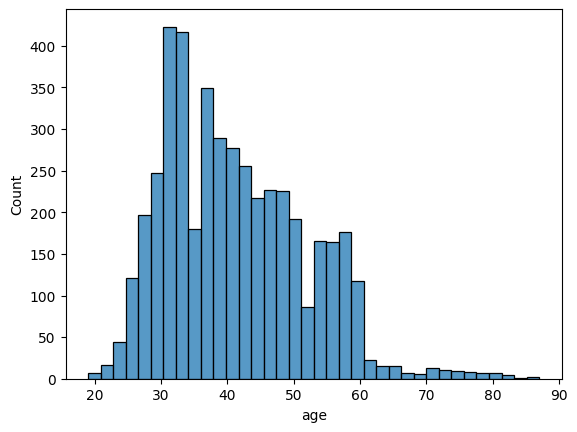

In [ ]:
sns.reset_orig()
sns.histplot(data=df,x='age')

Distribuciones de la variable job

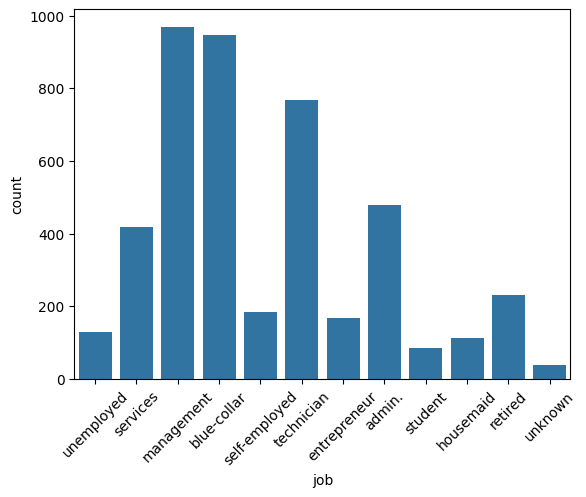

In [ ]:
sns.countplot(x="job", data=df)
plt.xticks(rotation=45)
plt.show()

La variable job muestra que los clientes con ocupaciones como admin. y blue-collar representan una gran proporción del dataset. Esto indica que las campañas de marketing han sido dirigidas principalmente hacia estos segmentos laborales.

Analisis de clientes segun la edad y si contrataron o no el servicio

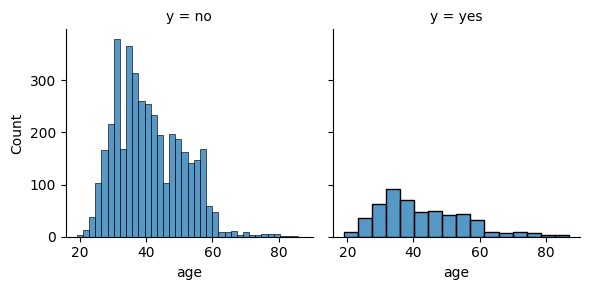

In [ ]:
g = sns.FacetGrid(df, col='y')
g.map(sns.histplot, 'age')

La edad, por sí sola, no presenta un poder discriminante fuerte entre clientes que se suscriben y los que no, aunque se observa una tendencia a una mayor probabilidad de suscripción en rangos etarios más elevados.

Analisis de duracion de llamadas con respecto a la variable objetivo

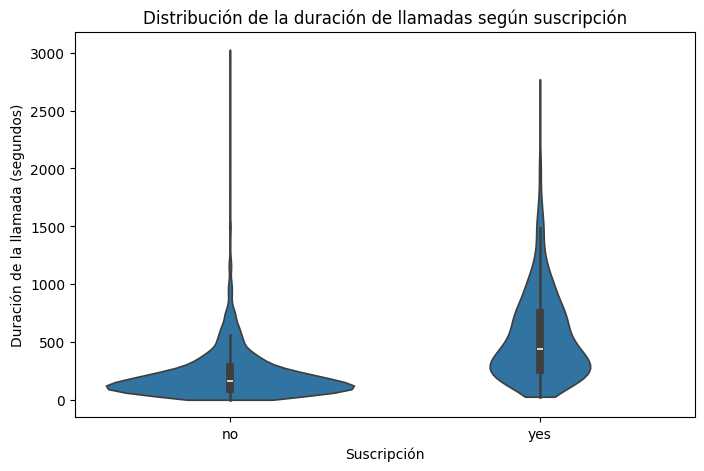

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.violinplot(
    data=df,
    x='y',
    y='duration',
    inner='box',
    cut=0
)

ax.set_title('Distribución de la duración de llamadas según suscripción')
ax.set_xlabel('Suscripción')
ax.set_ylabel('Duración de la llamada (segundos)')

plt.show()
plt.close()


Las llamadas que resultan en una suscripción tienden a ser considerablemente más largas que aquellas que no lo hacen, lo que sugiere que una interacción más extensa aumenta la probabilidad de éxito de la campaña.
La tasa de suscripción aumenta de manera significativa a medida que se incrementa la duración de la llamada, lo que indica que las llamadas más extensas son considerablemente más efectivas para concretar la venta del producto.

Analisis promedio de la duracion de llamadas realizadas

<Axes: ylabel='duration'>

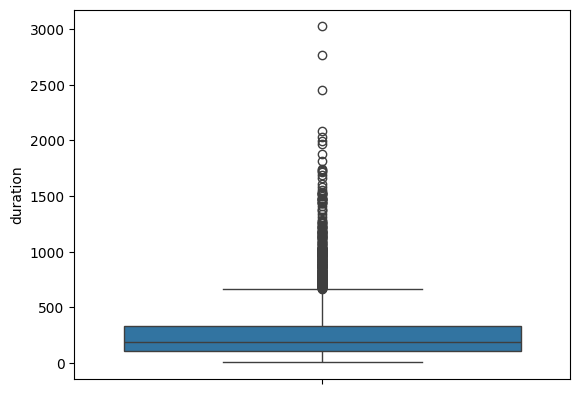

In [ ]:
sns.boxplot(df['duration'])

Edad + duración de llamada + aceptación de campaña

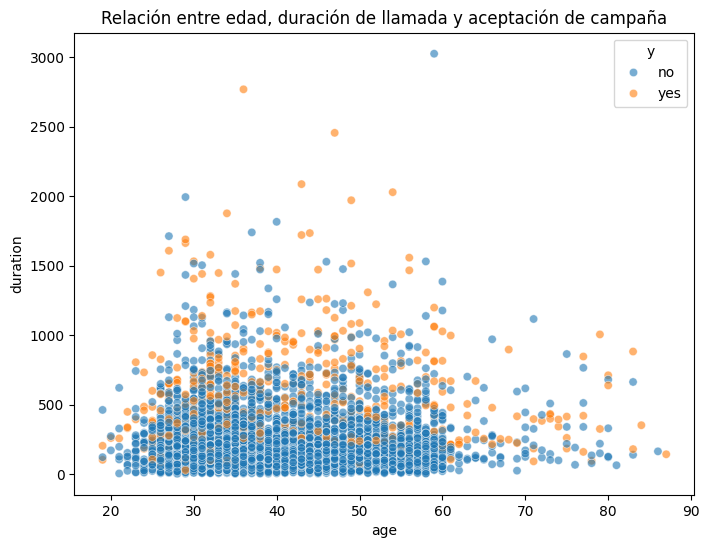

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="duration",
    hue="y",
    alpha=0.6
)

plt.title("Relación entre edad, duración de llamada y aceptación de campaña")
plt.show()

En este gráfico se observa la relación entre la edad del cliente, la duración de la llamada y el resultado de la campaña. Se puede notar que las llamadas con mayor duración tienden a estar más asociadas con respuestas positivas (yes). Esto sugiere que una mayor interacción con el cliente podría aumentar la probabilidad de conversión en la campaña de marketing.

Analisis multivariado de las variables con respecto a la variable target

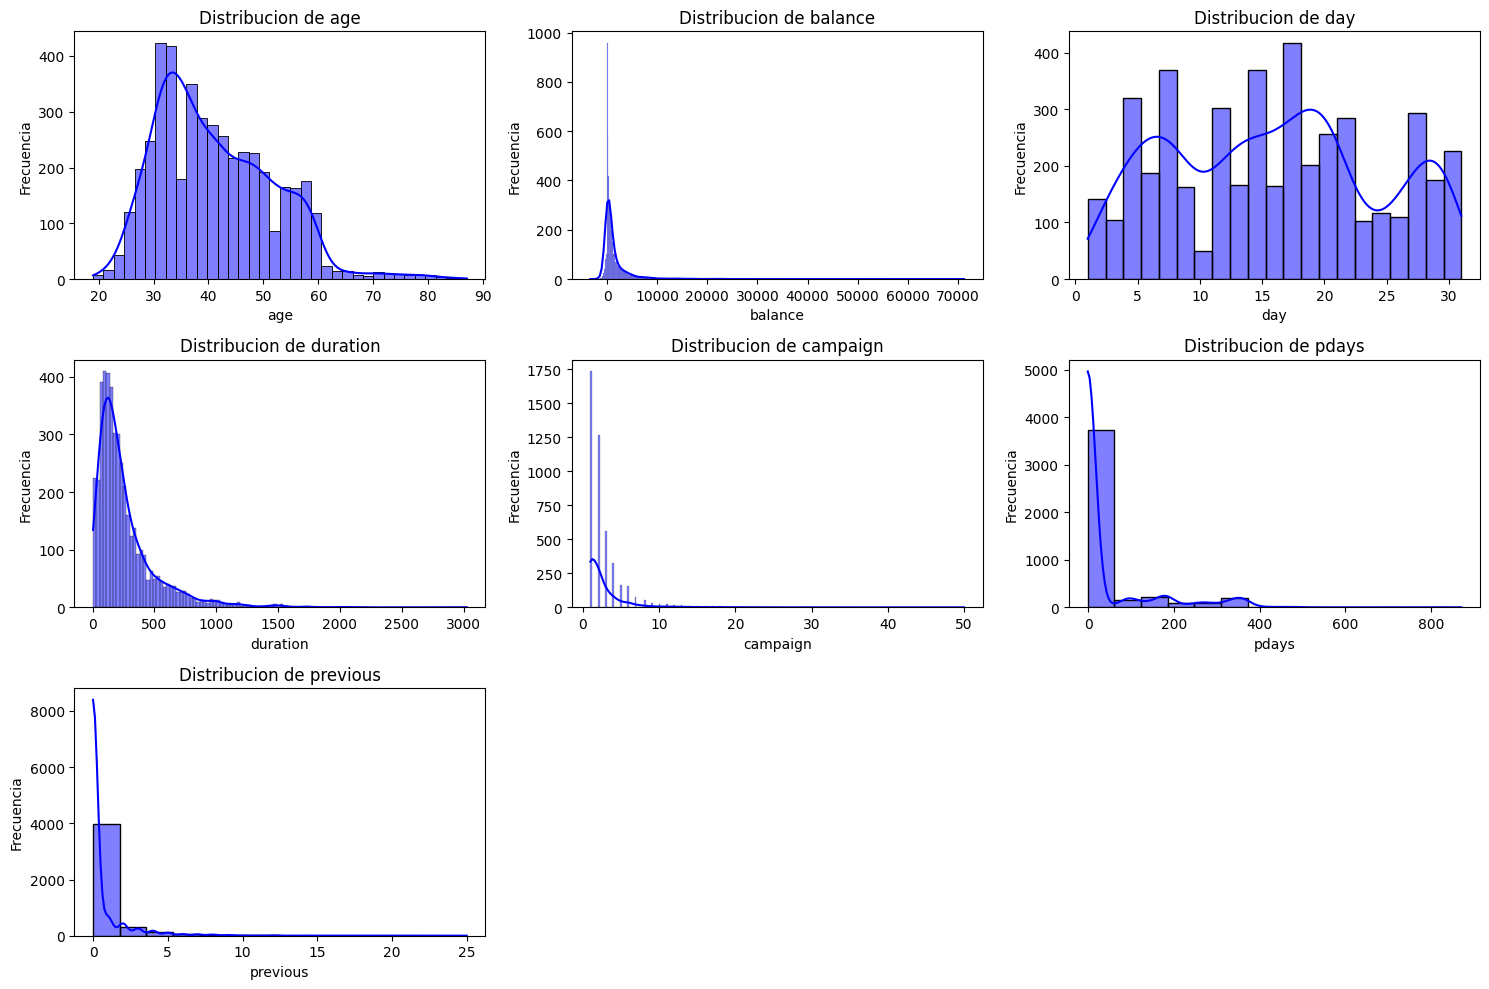

In [ ]:
#Columnas Numericas

Columnas_numericas= ['age','balance','day','duration','campaign','pdays','previous']

#Visualiazacion de distribucion

plt.figure(figsize=(15,10))
for i, columna in enumerate(Columnas_numericas,1):
  plt.subplot(3,3,i)
  sns.histplot(df[columna],kde=True , color = 'blue')
  plt.title(f'Distribucion de {columna}')
  plt.xlabel(columna)
  plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()



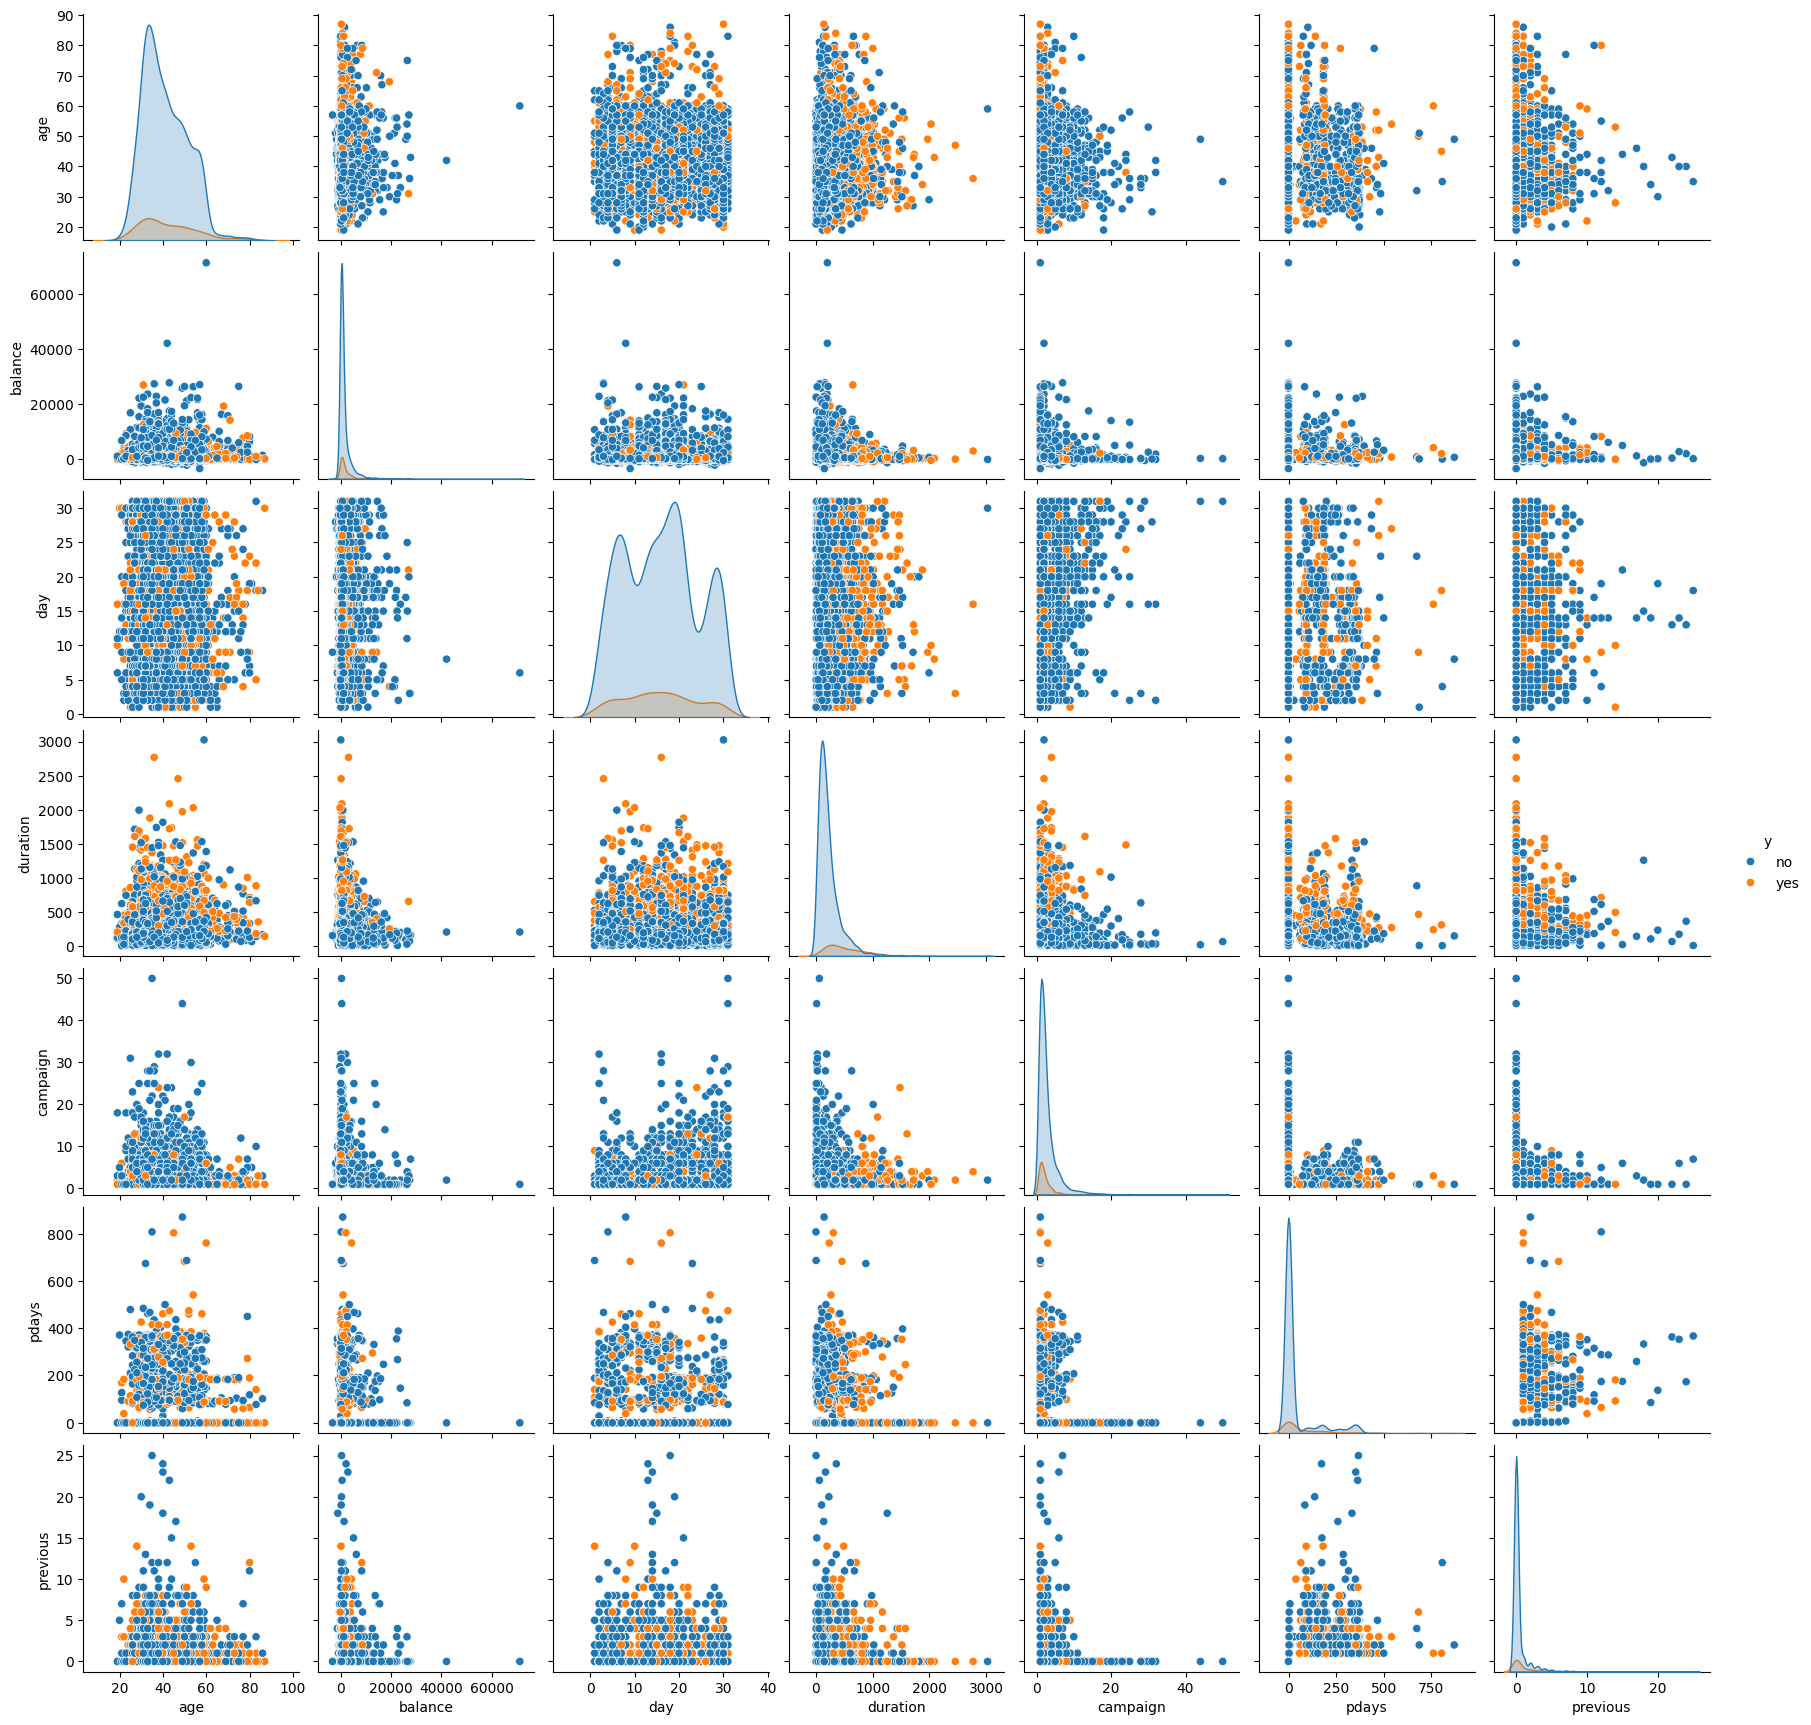

In [ ]:
sns.pairplot(df, hue='y')

# Visualizacion de Outliers


In [ ]:
#columnas numericas a analizar
Columnas_numericas= ['age','balance','day','duration','campaign','pdays','previous']

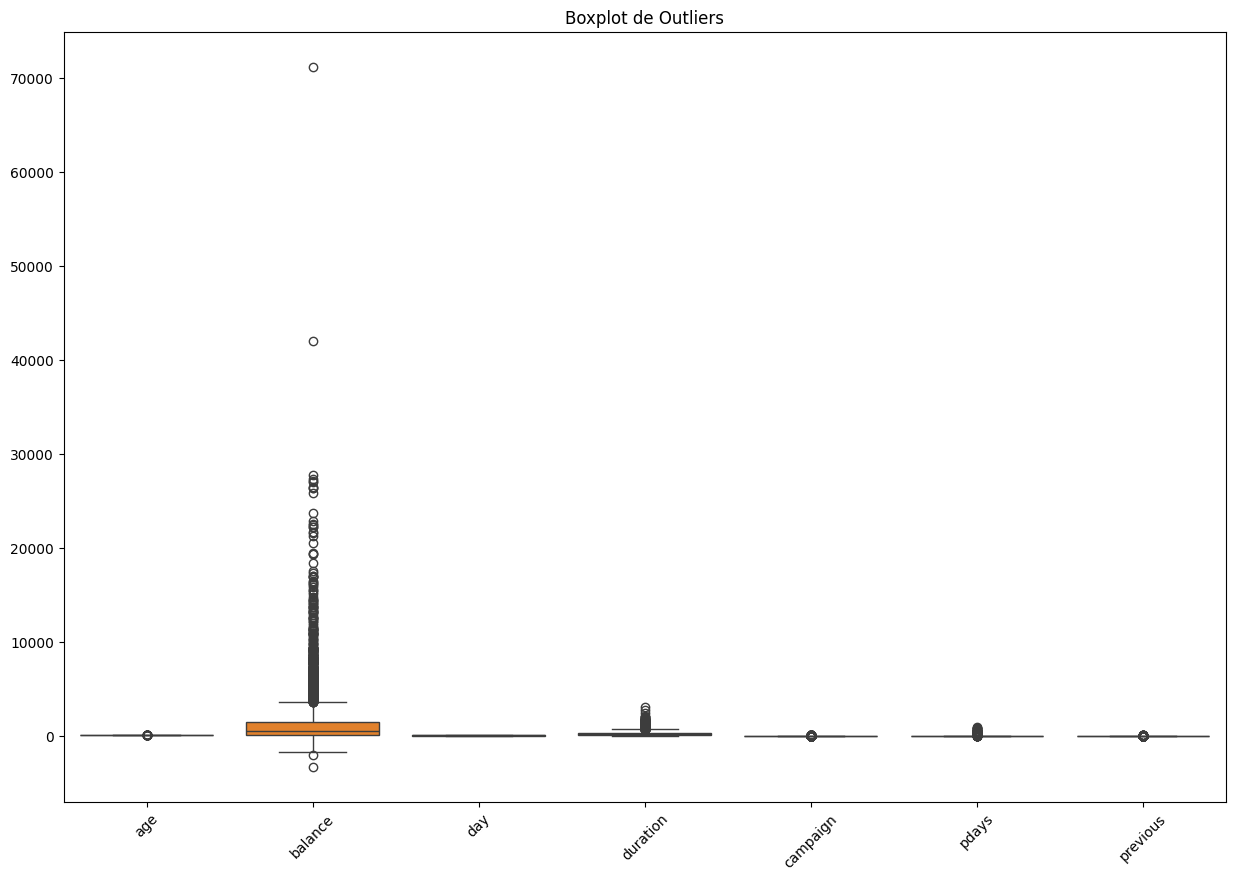

In [ ]:
#visualizacion de Outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=df[Columnas_numericas])
plt.title("Boxplot de Outliers")
plt.xticks(rotation=45)
plt.show()

Durante el análisis exploratorio se identificaron valores extremos en algunas variables numéricas como balance y duration. Sin embargo, estos valores representan comportamientos reales de clientes y no errores de registro. Por esta razón no se eliminaron observaciones. En su lugar se aplicó una transformación logarítmica para reducir la asimetría y disminuir la influencia de valores extremos en el entrenamiento del modelo.

# Preprocesamiento de datos

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# copia del dataset
df_model = df.copy()

Se crea una copia del dataset original para evitar modificar los datos utilizados durante el análisis exploratorio.

Transformación de variables sesgadas

In [ ]:
#tratamiento de las variables 'Balance' y 'Duration'
df_model['balance'] = np.log1p(df_model['balance'])
df_model['duration'] = np.log1p(df_model['duration'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Durante el EDA se observó que:


*   Balance
*   Duration

presentaban fuerte asimetría positiva.

La transformación logarítmica:

*   reduce la dispersión
*   estabiliza la varianza

mejora el rendimiento de modelos lineales.

In [ ]:
#tratamiento variable 'pdays', 999 significa que "no fue contactado" asi evitamos que se tome un valor real
df_model['previus_contact'] = (df_model['pdays'] !=999).astype(int)
df_model['pdays'] = df_model['pdays'].replace(999,0)

Tratamiento de pdays.
En el dataset pdays=999 significa que el cliente nunca fue contactado previamente.
Por eso se crea una variable binaria para indicar si hubo o no contacto previo.

# Separación de variables predictoras y objetivo

In [ ]:
#separacion features y target
X = df_model.drop('y', axis=1)
y = df_model['y'].map({'yes':1, 'no':0})

El objetivo es predecir si el cliente suscribirá un depósito a plazo.

In [ ]:
#Ientifica de variables numericas y categoricas
numeric_features = X.select_dtypes(include=['int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Pipeline de preprocesamiento

In [ ]:
#importamos librerias necesarias para preprocesamiento de datos
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Se construye un pipeline usando:
*   StandardScaler → variables numéricas
*   OneHotEncoder → variables categóricas

Esto permite:

* automatizar el preprocesamiento

* evitar data leakage

* reproducibilidad del modelo

TRAIN / TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Division Train/Test
se utiliza :
* 80% entrenamiento
* 20% test

# MODELO  — LOGISTIC REGRESSION

Se utiliza regresión logística como modelo base porque:

* es interpretable

* funciona bien en clasificación binaria

* permite establecer una referencia de desempeño.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    accuracy_score,
    recall_score
)

In [ ]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'day', 'campaign', 'pdays', 'previous', 'previus_contact'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

EVALUACIÓN LOGISTIC REGRESSION

In [ ]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [ ]:
print("====== Logistic Regression ======")
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_log))

====== Logistic Regression ======

Confusion Matrix
[[573 228]
 [ 38  66]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.72      0.81       801
           1       0.22      0.63      0.33       104

    accuracy                           0.71       905
   macro avg       0.58      0.67      0.57       905
weighted avg       0.86      0.71      0.76       905


ROC-AUC: 0.735006722366273


# MODELO  — RANDOM FOREST

Se entrena un modelo de Random Forest para capturar:

* relaciones no lineales

* interacciones entre variables.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'day', 'campaign', 'pdays', 'previous', 'previus_contact'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

EVALUACIÓN RANDOM FOREST

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\n====== Random Forest ======")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))


====== Random Forest ======

Confusion Matrix
[[789  12]
 [ 92  12]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       801
           1       0.50      0.12      0.19       104

    accuracy                           0.89       905
   macro avg       0.70      0.55      0.56       905
weighted avg       0.85      0.89      0.85       905


ROC-AUC: 0.7072409488139825


# MODELO — XGBOOST

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'day', 'campaign', 'pdays', 'previous', 'previus_contact'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'day', 'campaign', 'pdays', 'previous', 'previus_contact'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

EVALUACIÓN XGBOOST

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("\n====== XGBoost ======")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


====== XGBoost ======

Confusion Matrix
[[788  13]
 [ 86  18]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       801
           1       0.58      0.17      0.27       104

    accuracy                           0.89       905
   macro avg       0.74      0.58      0.60       905
weighted avg       0.86      0.89      0.86       905


ROC-AUC: 0.7521607605877269


#  CURVA ROC

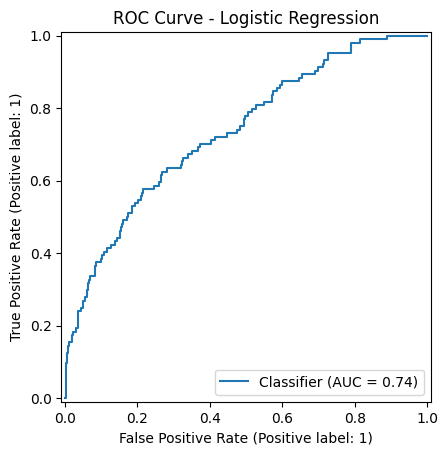

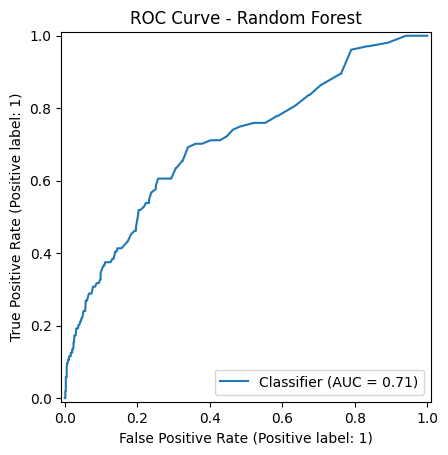

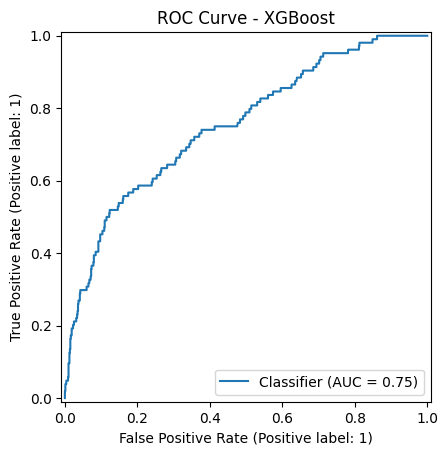

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob_log)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()


# Predicciones de cada modelo

In [ ]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

Calcular métricas

In [ ]:
accuracy_log = accuracy_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

Crea tabla comparativa

In [ ]:
resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_log, accuracy_rf, accuracy_xgb],
    "Recall": [recall_log, recall_rf, recall_xgb]
})
resultados

,Modelo,Accuracy,Recall
0,Logistic Regression,0.706077,0.634615
1,Random Forest,0.885083,0.115385
2,XGBoost,0.890608,0.173077


Matriz de Confusion

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

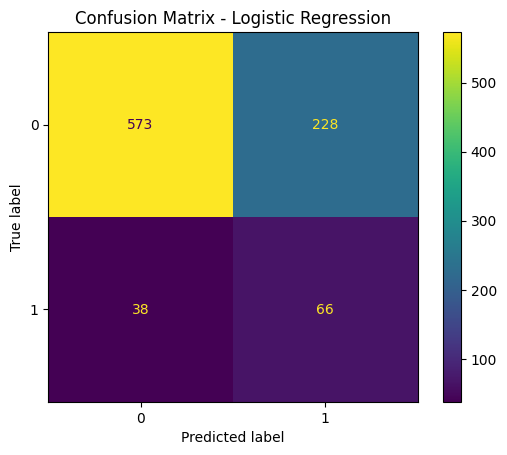

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Conclusión

El objetivo de este proyecto fue desarrollar un modelo de Machine Learning capaz de predecir si un cliente aceptará una campaña de marketing bancario utilizando información demográfica y financiera. Para ello se entrenaron y evaluaron tres modelos de clasificación: Logistic Regression, Random Forest y XGBoost.

Los resultados muestran que los modelos basados en árboles presentan un mejor desempeño que el modelo lineal. Random Forest mejora la capacidad predictiva al capturar relaciones no lineales entre las variables, mientras que XGBoost obtiene el mejor rendimiento general en las métricas evaluadas.

A pesar de su menor performance, Logistic Regression resulta útil como modelo base debido a su simplicidad e interpretabilidad. Sin embargo, para un escenario productivo, XGBoost se presenta como la mejor alternativa al lograr un mayor poder de discriminación entre clientes que aceptan o no la campaña.

En conclusión, la utilización de modelos de Machine Learning permite identificar patrones relevantes en los datos y puede convertirse en una herramienta valiosa para optimizar campañas de marketing, focalizando los esfuerzos comerciales en clientes con mayor probabilidad de conversión.